# Dhruv Khanna

# Exercise: Regression

Please load `regression_exercise.csv` and predict `real_est_sales.csv` using the same regression models we used in the demo (i.e. linear regression, decision tree regression, and K-nearest neighbor regression). Answer the following questions and include your final code below. When you are done, click on Run > Restart Kernel and Run All Cells... and verify the output.
- Q: How did you encode `Neighborhood` and `House old` and why?
- A: One-hot encoding was applied to the 'Neighborhood' and 'Household' variables using pd.get_dummies, with drop_first=True specified to reduce multicollinearity by excluding one category from each variable.

- Q: 80%: 20% to Train: Test datasets; How many observations are in your train and test datasets? 
- A: The training set includes 39,722 observations. The test set, with 9,931 observations.

- Q: What is the R-squared value for linear regression fitted model?
- A: The model's R-squared value for lr(X_train and y_train is  and for lr (X_test,y_test) is 0.57 (0.567582406265424).

- Q: Which regression model performs the best and why (i.e. has the lowest mean absolute error)?
- A: The Linear Regression model outperforms the others with the lowest Mean Absolute Error of 39,085.22, indicating superior predictive accuracy and making it the most reliable choice for this dataset.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns

In [5]:
df = pd.read_csv('real_est_sales.csv')

In [6]:
df.head()

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price,House old
0,40145,1006,2,1,Suburb,1973,225690.0,Old
1,17217,1013,2,1,Suburb,2018,225690.0,Young
2,36236,1112,3,1,Suburb,1978,225690.0,Old
3,29981,1005,3,3,Urban,1978,225690.0,Old
4,23663,1256,3,1,Rural,1978,225690.0,Old


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49653 entries, 0 to 49652
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            49653 non-null  int64  
 1   SquareFeet    49653 non-null  int64  
 2   Bedrooms      49653 non-null  int64  
 3   Bathrooms     49653 non-null  int64  
 4   Neighborhood  49653 non-null  object 
 5   YearBuilt     49653 non-null  int64  
 6   Price         49653 non-null  float64
 7   House old     49653 non-null  object 
dtypes: float64(1), int64(5), object(2)
memory usage: 3.0+ MB


In [8]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
id,49653.0,24997.51,14433.62,1.0,12498.0,24991.0,37494.0,50004.0
SquareFeet,49653.0,2012.09,573.29,1000.0,1522.0,2015.0,2509.0,2999.0
Bedrooms,49653.0,3.50,1.12,2.0,3.0,3.0,4.0,5.0
Bathrooms,49653.0,2.00,0.82,1.0,1.0,2.0,3.0,3.0
YearBuilt,49653.0,1985.39,20.72,1950.0,1967.0,1985.0,2003.0,2021.0
Price,49653.0,226064.78,74372.69,50141.0,171168.0,225690.0,279715.0,442624.0


In [9]:
CM = df.select_dtypes('number').corr().round(2)

In [10]:
CM

,id,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
id,1.00,-0.00,-0.00,0.00,-0.01,-0.00
SquareFeet,-0.00,1.00,-0.01,-0.00,0.00,0.75
Bedrooms,-0.00,-0.01,1.00,0.01,0.00,0.07
Bathrooms,0.00,-0.00,0.01,1.00,0.00,0.03
YearBuilt,-0.01,0.00,0.00,0.00,1.00,-0.00
Price,-0.00,0.75,0.07,0.03,-0.00,1.00


<Axes: >

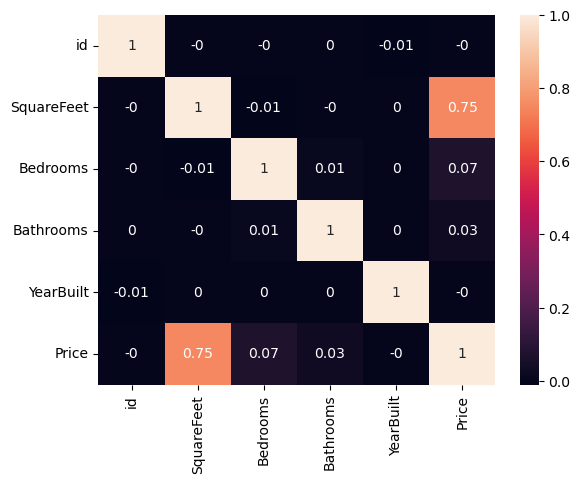

In [11]:
sns.heatmap(CM, annot=True)

In [12]:
df['Neighborhood'].value_counts()

Neighborhood
Suburb    16607
Rural     16558
Urban     16488
Name: count, dtype: int64

In [13]:
df['House old'].value_counts()

House old
Old      38790
Young    10863
Name: count, dtype: int64

<Axes: xlabel='Neighborhood', ylabel='count'>

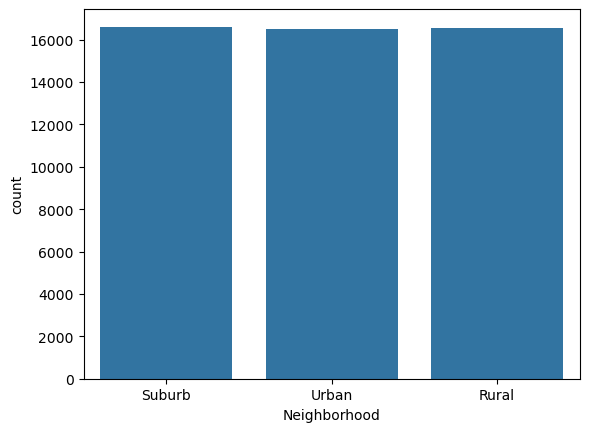

In [14]:
sns.countplot(data=df, x='Neighborhood')

<Axes: xlabel='House old', ylabel='count'>

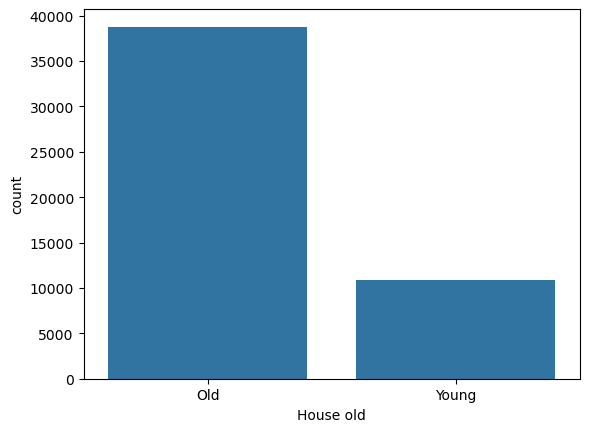

In [15]:
sns.countplot(data=df, x='House old')

<Axes: xlabel='Neighborhood', ylabel='count'>

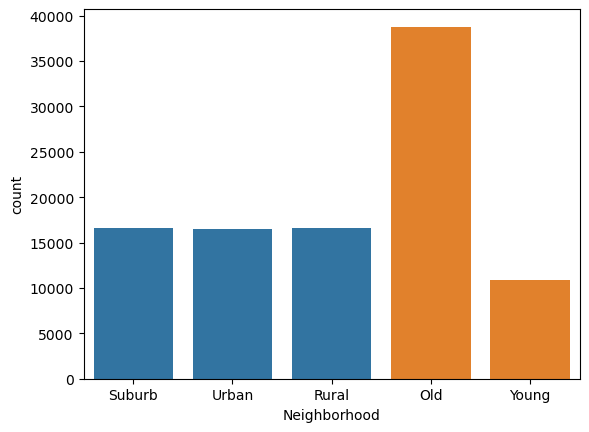

In [16]:
sns.countplot(data=df, x='Neighborhood')
sns.countplot(data=df, x='House old')

In [17]:
df = pd.get_dummies(data=df, columns=['Neighborhood', 'House old'], drop_first=True)

In [18]:
df.head()

,id,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price,Neighborhood_Suburb,Neighborhood_Urban,House old_Young
0,40145,1006,2,1,1973,225690.0,True,False,False
1,17217,1013,2,1,2018,225690.0,True,False,True
2,36236,1112,3,1,1978,225690.0,True,False,False
3,29981,1005,3,3,1978,225690.0,False,True,False
4,23663,1256,3,1,1978,225690.0,False,False,False


In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
numerical_features = ['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt']

In [21]:
scaler = StandardScaler()

In [22]:
scaled_features = scaler.fit_transform(df[numerical_features])

In [23]:
scaled_df = pd.DataFrame(scaled_features, columns=numerical_features, index=df.index)

In [24]:
df[numerical_features] = scaled_df

In [25]:
df.head()

,id,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price,Neighborhood_Suburb,Neighborhood_Urban,House old_Young
0,40145,-1.754952,-1.344716,-1.220725,-0.598021,225690.0,True,False,False
1,17217,-1.742742,-1.344716,-1.220725,1.573991,225690.0,True,False,True
2,36236,-1.570053,-0.448750,-1.220725,-0.356686,225690.0,True,False,False
3,29981,-1.756697,-0.448750,1.230797,-0.356686,225690.0,False,True,False
4,23663,-1.318869,-0.448750,-1.220725,-0.356686,225690.0,False,False,False


In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X = df.drop(columns=['Price', 'id'])

In [28]:
y = df['Price']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

X_train shape: (39722, 7), X_test shape: (9931, 7)
y_train shape: (39722,), y_test shape: (9931,)


In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
lr = LinearRegression()

In [33]:
lr.fit(X_train, y_train)

LinearRegression()

In [34]:
pred_lr = lr.predict(X_test)

In [35]:
pred_lr

array([223767.40529426, 186701.34383772, 181564.60844945, ...,
       320747.98808465, 303931.5410269 , 144684.31249877])

In [112]:
lr.score(X_train, y_train)

0.5640873316583533

In [116]:
lr.score(X_test, y_test)

0.567582406265424

In [38]:
from sklearn.tree import DecisionTreeRegressor

In [39]:
dtr = DecisionTreeRegressor(random_state=42)

In [40]:
dtr.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [41]:
pred_dtr = dtr.predict(X_test)

In [42]:
pred_dtr

array([227677., 158437., 163074., ..., 287991., 290025., 118136.])

In [43]:
from sklearn.neighbors import KNeighborsRegressor

In [44]:
knr = KNeighborsRegressor(n_neighbors=5)

In [45]:
knr.fit(X_train, y_train)

KNeighborsRegressor()

In [46]:
pred_knr = knr.predict(X_test)

In [47]:
pred_knr

array([254924.8, 133637. , 163140.4, ..., 359565.6, 309026.8, 143274.6])

In [48]:
from sklearn.metrics import mean_absolute_error, r2_score

In [49]:
mae_lr = mean_absolute_error(y_test, pred_lr)
mae_dtr = mean_absolute_error(y_test, pred_dtr)
mae_knr = mean_absolute_error(y_test, pred_knr)

In [104]:
mae_lr

42624.6737891451

In [106]:
mae_dtr

57045.48716141375

In [108]:
mae_knr

42624.6737891451